# Section 4 - Exploration of the embedding space for discovery - MoA and targets

In [1]:
# IMPORT NEEDED PACKAGES 
import pandas as pd
import numpy as np
import h5py

from tqdm import tqdm
import pickle
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import ast

import warnings
warnings.filterwarnings("ignore")

# PATHS
path_save = './LINCS_scGPT_embeddings/Results/compound_genetic_similarity/'
root_LINCS = './LINCS_scGPT_embeddings/02_Obtain_Embeddings/embeddings_full.h5ad'

adata = sc.read(root_LINCS)


/aloy/home/epareja/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# 1. Compound - sh relationship.

In [ ]:
## Distances and indices
# =============================================================================
# You need to run ./LINCS_scGPT_embeddings/03_Distance_Integration/NN_calculation.py using: 
# - reference: embeddings of compounds (trt_cp)
# - query: embeddings of genetic perturbations (trt_sh)


## Robustness ranking

In [113]:
output_path = path_save + 'cmpvssh_nn.h5'
with h5py.File(output_path, 'r') as f:
    indices = f['indices'][:]

sig_id_order_cmp = pickle.load(open(path_save + 'order_sig_cmp.pkl', 'rb'))
sig_id_order_sh  = pickle.load(open(path_save + 'order_sig_sh.pkl',  'rb'))

Processing scGPT - FT


In [115]:
sig2cmap = dict(zip(adata.obs.index, adata.obs['cmap_name']))

/tmp/ipykernel_403327/2184008154.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  inst_info = pd.read_csv('/aloy/home/epareja/2024/LINCS-scGPT/Data/LINCS/Metadata/instinfo_beta.txt', sep = '\t')


In [118]:
cmap_order_cmp = [sig2cmap[i] for i in sig_id_order_cmp]

cmap_order_cmp = [sig2cmap[i] for i in sig_id_order_cmp]
cmap_order_sh = [sig2cmap[i] for i in sig_id_order_sh]

gene_by_sh_index = np.array(cmap_order_sh, dtype=object)


def topk_unique_genes_per_row(indices, gene_by_sh_index, K_genes=100, max_scan=None):
    """
    indices: (n_rows, K0) int array of ranked sh indices (neighbors).
    gene_by_sh_index: array-like mapping sh_idx -> gene (str or None)
    K_genes: number of unique genes to collect per row
    max_scan: how many sh neighbors to scan per row (default = all columns)

    Returns:
      genes_mat: (n_rows, K_genes) object array with gene symbols, padded with None if not enough genes.
    """
    n_rows, K0 = indices.shape
    if max_scan is None:
        max_scan = K0

    genes_mat = np.full((n_rows, K_genes), None, dtype=object)

    for i in tqdm(range(n_rows)):
        seen = set()
        out = []
        for sh in indices[i, :max_scan]:
            g = gene_by_sh_index[sh]
            if g is None:
                continue
            if g not in seen:
                seen.add(g)
                out.append(g)
                if len(out) == K_genes:
                    break
        genes_mat[i, :len(out)] = out

    return genes_mat


import pandas as pd


def build_compound_gene_robustness(
    indices,
    gene_by_sh_index,
    sig_id_order_cmp,
    cmap_order_cmp,
    K_genes=100,
    max_scan=None,
):
    genes_mat = topk_unique_genes_per_row(
        indices,
        gene_by_sh_index,
        K_genes=K_genes,
        max_scan=max_scan,
    )

    n_rows = genes_mat.shape[0]
    cp_sig = np.repeat(np.array(sig_id_order_cmp, dtype=object), genes_mat.shape[1])
    cp_name = np.repeat(np.array(cmap_order_cmp, dtype=object), genes_mat.shape[1])
    gene = genes_mat.reshape(-1)

    df_pairs = pd.DataFrame({
        "cp_sig": cp_sig,
        "compound": cp_name,
        "gene": gene,
    }).dropna(subset=["gene"]).copy()

    df_pairs = df_pairs.drop_duplicates(subset=["cp_sig", "gene"])

    support = (
        df_pairs.groupby(["compound", "gene"])["cp_sig"]
        .nunique()
        .rename("n_support")
        .reset_index()
    )

    n_cp_sigs = (
        pd.Series(cmap_order_cmp)
        .value_counts()
        .rename("n_cp_sigs")
        .reset_index()
        .rename(columns={"index": "compound"})
    )

    cg = support.merge(n_cp_sigs, on="compound", how="left")
    cg["robustness"] = cg["n_support"] / cg["n_cp_sigs"]

    # Build compound x top-K genes table ordered by robustness
    ranked = (
        cg.sort_values(["compound", "robustness"], ascending=[True, False])
        .groupby("compound", sort=False)
        .head(K_genes)
    )
    ranked["rank"] = ranked.groupby("compound").cumcount() + 1
    top_genes_df = ranked.pivot(index="compound", columns="rank", values="gene")
    top_genes_df.columns = [f"gene_{c}" for c in top_genes_df.columns]
    top_genes_df = top_genes_df.reset_index()

    return cg, genes_mat, top_genes_df


cg, genes_mat, top_genes_df = build_compound_gene_robustness(
    indices,
    gene_by_sh_index,
    sig_id_order_cmp,
    cmap_order_cmp,
    K_genes=100,
)
K_GENES = genes_mat.shape[1]
top_genes_df.to_csv(path_save + "compound_top_genes_robustness.csv", index=False)

  0%|          | 0/209242 [00:00<?, ?it/s]

## Confidence scoring for full-dataset robustness gene lists

For each of the 33,609 compounds with a robustness top-100 gene list, we compute four
independent confidence scores and combine them into a composite. Compounds are then
ranked and a deliverable CSV is produced with the top-confidence compounds and their
full top-100 gene list.

**Score 1 — Replication depth (`score_n_sigs`)**: compounds with more independent
signatures have more reliable robustness estimates. 

**Score 2 — Transcriptional activity (`score_tas`)**: mean TAS across signatures.
Low TAS means the compound barely perturbs transcription, so the gene list is noisy.

**Score 3 — Enrichment coherence (`score_enrichment`)**: whether the top-100 genes are
enriched in any coherent pathway (regardless of known target). A compound whose top-100
genes hit no GO/KEGG term is likely noise. 

**Score 4 - Robustness (`score_robustness`)**: Mean robustness score of the top 100 genes for each compound.

All scores are min-max normalised to [0,1]; the composite is their mean.


In [ ]:
# Full robustness top-100 table (all compounds)
gene_cols = [c for c in top_genes_df.columns if c.startswith("gene_")]
print(f"Full top-genes table: {top_genes_df.shape[0]:,} compounds x {len(gene_cols)} gene slots")

Full top-genes table: 33,609 compounds x 100 gene slots


In [ ]:
# Score 1: replication depth — number of QC-passing signatures per compound
n_sigs_per_cmp = (
    adata[(adata.obs['pert_type'] == 'trt_cp') & (adata.obs['qc_pass'] == '1')].obs
    .groupby('cmap_name')['sample_id']
    .nunique()
    .rename('n_sigs')
    .reset_index()
    .rename(columns={'cmap_name': 'compound'})
)

conf = top_genes_df[['compound']].merge(n_sigs_per_cmp, on='compound', how='left')
conf['n_sigs'] = conf['n_sigs'].fillna(1).astype(int)

# log-scale then min-max normalise (diminishing returns on >100 sigs)
conf['score_n_sigs'] = np.log1p(conf['n_sigs'])
conf['score_n_sigs'] = (conf['score_n_sigs'] - conf['score_n_sigs'].min()) /(conf['score_n_sigs'].max() - conf['score_n_sigs'].min())

print("Score 1 (n_sigs) distribution:")
print(conf['score_n_sigs'].describe().round(3))


Score 1 (n_sigs) distribution:
count    33609.000
mean         0.185
std          0.174
min          0.000
25%          0.049
50%          0.132
75%          0.294
max          1.000
Name: score_n_sigs, dtype: float64


In [ ]:
# Score 2: transcriptional activity score — mean TAS per compound
mean_tas_per_cmp = (
    adata[adata.obs['pert_type'] == 'trt_cp'].obs
    .groupby('cmap_name')['tas']
    .mean()
    .rename('mean_tas')
    .reset_index()
    .rename(columns={'cmap_name': 'compound'})
)

conf = conf.merge(mean_tas_per_cmp, on='compound', how='left')
conf['mean_tas'] = conf['mean_tas'].fillna(0)

conf['score_tas'] = (conf['mean_tas'] - conf['mean_tas'].min()) /(conf['mean_tas'].max() - conf['mean_tas'].min())

print("Score 2 (TAS) distribution:")
print(conf['score_tas'].describe().round(3))


Score 2 (TAS) distribution:
count    33609.000
mean         0.141
std          0.093
min          0.000
25%          0.087
50%          0.132
75%          0.183
max          1.000
Name: score_tas, dtype: float64


In [ ]:
# Score 3: enrichment coherence 
# Strategy: download GO_BP gene sets once, build a sparse term x gene matrix,
# then compute overlaps for all compounds via a single matrix multiply,
# followed by vectorised hypergeometric tests + BH correction.

from scipy.sparse import csr_matrix
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

ENRICH_LIBS_paths = {
    'GO_BP': './LINCS_scGPT_embeddings/04_Knowledge_Extraction/geneSetLibrary_BP.txt',
    'KEGG':  './LINCS_scGPT_embeddings/04_Knowledge_Extraction/geneSetLibrary_KEGG.txt',
    'Reactome': './LINCS_scGPT_embeddings/04_Knowledge_Extraction/geneSetLibrary_Reactome.txt',
}

def load_gmt_from_enrichr(path):

    gene_sets = {}
    with open(path, 'r') as f:
        raw = f.read()
    for line in raw.strip().split('\n'):
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            gene_sets[parts[0]] = [g for g in parts[2:] if g]
    return gene_sets

print('Downloading gene set libraries (once)...')
combined_sets = {}
for lib_name, path in ENRICH_LIBS_paths.items():
    gs = load_gmt_from_enrichr(path)
    combined_sets.update(gs)
    print(f'  {lib_name}: {len(gs)} terms')

# Gene universe and term-gene sparse matrix
all_genes_enrich = sorted(set(g for gs in combined_sets.values() for g in gs))
gene2idx_enrich = {g: i for i, g in enumerate(all_genes_enrich)}
N_BG = len(all_genes_enrich)

term_names_all = list(combined_sets.keys())
term_sizes_all = np.array([len(combined_sets[t]) for t in term_names_all])
# Keep terms with 10-500 genes (informative, not too broad)
term_mask = (term_sizes_all >= 10) & (term_sizes_all <= 500)
term_names_f = [term_names_all[i] for i in np.where(term_mask)[0]]
term_sizes_f = term_sizes_all[term_mask].astype(float)

rows_mat, cols_mat = [], []
for ti, tn in enumerate(term_names_f):
    for g in combined_sets[tn]:
        if g in gene2idx_enrich:
            rows_mat.append(ti)
            cols_mat.append(gene2idx_enrich[g])
term_gene_mat = csr_matrix(
    (np.ones(len(rows_mat)), (rows_mat, cols_mat)),
    shape=(len(term_names_f), N_BG), dtype=np.float32
)
print(f'Term-gene matrix: {term_gene_mat.shape[0]} terms x {N_BG} genes')


  GO_BP: 5954 terms
  KEGG: 352 terms
  Reactome: 2105 terms
Term-gene matrix: 5848 terms x 17340 genes


In [ ]:
# Build compound-gene matrix from top_genes_full and compute enrichment for all compounds.
# Uses sparse matrix multiply to get overlaps, then vectorised hypergeometric test.
# BH correction across compounds, using one best p-value per compound
# per-compound correction and conservative in the right direction.
BATCH = 500

compound_list = top_genes_df['compound'].tolist()
N_CMP = len(compound_list)
n_terms = len(term_names_f)

def get_top_genes_for_compound(top_genes_df, compound, k=100):
    row = top_genes_df[top_genes_df["compound"] == compound]
    if row.empty:
        return []
    gene_cols = [c for c in top_genes_df.columns if c.startswith("gene_")]
    genes = row[gene_cols].values.flatten().tolist()
    return [g for g in genes if isinstance(g, str)][:k]


# Pass 1: compute raw overlaps and p-values, store best raw p per compound
best_raw_p = np.ones(N_CMP)  # worst case = 1.0
n_queries = np.zeros(N_CMP, dtype=int)

for start in tqdm(range(0, N_CMP, BATCH), desc='Enrichment'):
    end = min(start + BATCH, N_CMP)
    B = end - start

    cmp_mat = np.zeros((B, N_BG), dtype=np.float32)
    for i, compound in enumerate(compound_list[start:end]):
        genes = get_top_genes_for_compound(top_genes_df, compound)
        idxs = [gene2idx_enrich[g] for g in genes if g in gene2idx_enrich]
        if idxs:
            cmp_mat[i, idxs] = 1.0
            n_queries[start + i] = len(idxs)

    overlap = (csr_matrix(cmp_mat) @ term_gene_mat.T).toarray().astype(float)

    nz_i, nz_j = np.where(overlap > 0)
    if len(nz_i) == 0:
        continue

    k_nz  = overlap[nz_i, nz_j] # k: overlap between compound i and term j
    K_nz  = term_sizes_f[nz_j] # K: size of term j
    n_nz  = n_queries[start + nz_i].astype(float) # n: number of genes in compound i
    # N_BG is defined above as the total number of genes in the background universe
    pv_nz = hypergeom.sf(k_nz - 1, N_BG, K_nz, n_nz)

    # Store minimum raw p per compound in this batch
    for local_i, pv in zip(nz_i, pv_nz):
        global_i = start + local_i
        if pv < best_raw_p[global_i]:
            best_raw_p[global_i] = pv

# Pass 2: global BH correction on the per-compound best p-values
has_result = n_queries > 0
adj_p = np.ones(N_CMP)
if has_result.any():
    _, adj_sub, _, _ = multipletests(best_raw_p[has_result], method='fdr_bh')
    adj_p[has_result] = adj_sub

enrich_score_raw = -np.log10(np.maximum(adj_p, 1e-300))
enrich_score_raw[~has_result] = 0.0

conf['enrich_score_raw'] = conf['compound'].map(
    pd.Series(enrich_score_raw, index=compound_list)
).fillna(0.0)

vmax = conf['enrich_score_raw'].max()
conf['score_enrichment'] = conf['enrich_score_raw'] / vmax if vmax > 0 else 0.0

print('Score 3 (enrichment coherence) distribution:')
print(conf['score_enrichment'].describe().round(3))
n_enriched = (conf['enrich_score_raw'] > 0).sum()
print(f'Compounds with enrichment signal: {n_enriched:,} / {N_CMP:,} ({100*n_enriched/N_CMP:.1f}%)')



Enrichment:   0%|          | 0/68 [00:00<?, ?it/s]

Enrichment: 100%|██████████| 68/68 [45:58<00:00, 40.57s/it]

Score 4 (enrichment coherence) distribution:
count    33609.000
mean         0.209
std          0.115
min          0.067
25%          0.137
50%          0.173
75%          0.234
max          1.000
Name: score_enrichment, dtype: float64
Compounds with enrichment signal: 33,609 / 33,609 (100.0%)


In [153]:
cmp2robustness_100 = (
    cg
    .sort_values('robustness', ascending=False)
    .groupby('compound', sort=False)
    .head(100)
).groupby('compound')['robustness'].mean().sort_values(ascending=False).to_dict()

conf['robustness_100'] = conf['compound'].map(cmp2robustness_100)
conf['score_robustness'] = (conf['robustness_100'] - conf['robustness_100'].min()) /(conf['robustness_100'].max() - conf['robustness_100'].min())



In [ ]:
conf['composite_score'] = conf[['score_n_sigs', 'score_tas', 'score_enrichment', 'score_robustness']].mean(axis=1)
# conf.to_csv(path_save + "compound_robustness_confidence.csv", index=False)

# 2. Benchmark example: FROGS (and selection of threshold)

In [ ]:
# =============================================================================
# Download the cmp to target mapping from FRoGS github repo (https://github.com/chenhcs/FRoGS/blob/main/data/cpd_gene_pairs.csv)
# cp2sh_frogs = pickle.load(open('./cpd2target_names.pkl', 'rb'))

In [221]:
import numpy as np
import pandas as pd

def compute_best_target_position(top_genes_df, cp2sh_frogs, K_genes=100):
    """
    For each compound in cp2sh_frogs, find the best/earliest rank at which
    one of its known target genes appears in top_genes_df.

    Parameters
    ----------
    top_genes_df : pd.DataFrame
        DataFrame with columns: compound, gene_1, ..., gene_100

    cp2sh_frogs : dict
        Dictionary mapping compound -> list of known target genes

    K_genes : int
        Number of ranked genes to scan. Default = 100.

    Returns
    -------
    pd.DataFrame
        One row per compound with overlap statistics and best target position.
    """

    gene_cols = [f"gene_{i}" for i in range(1, K_genes + 1)]

    # Normalize compound names for matching
    top_df = top_genes_df.copy()
    top_df["_compound_key"] = top_df["compound"].astype(str).str.strip().str.casefold()

    # Build compound -> ranked predicted genes
    comp_to_pred = {}
    comp_to_original_name = {}

    for _, row in top_df.iterrows():
        key = row["_compound_key"]
        genes = [
            row[col]
            for col in gene_cols
            if col in top_df.columns and isinstance(row[col], str)
        ]

        comp_to_pred[key] = genes
        comp_to_original_name[key] = row["compound"]

    records = []

    for compound, known_targets in cp2sh_frogs.items():

        compound_key = str(compound).strip().casefold()

        # Normalize target gene names
        target_set = {
            str(g).strip().upper()
            for g in known_targets
            if isinstance(g, str)
        }

        if compound_key not in comp_to_pred:
            records.append({
                "compound": compound,
                "matched_compound": np.nan,
                "n_known_targets": len(target_set),
                "n_overlap": np.nan,
                "target_recall": np.nan,
                "target_precision": np.nan,
                "best_target_rank": np.nan,
                "best_target_gene": np.nan,
                "overlapping_targets": np.nan,
                "note": "compound_not_in_top_genes_df"
            })
            continue

        pred_genes = comp_to_pred[compound_key]

        # Normalize predicted genes for matching
        pred_genes_norm = [
            str(g).strip().upper()
            for g in pred_genes
            if isinstance(g, str)
        ]

        pred_set = set(pred_genes_norm)

        overlap = target_set & pred_set
        n_overlap = len(overlap)

        target_recall = n_overlap / len(target_set) if len(target_set) > 0 else 0.0
        target_precision = n_overlap / len(pred_set) if len(pred_set) > 0 else 0.0

        # Same logic as best_overlap_rank:
        # scan ranked genes from gene_1 to gene_100 and stop at first overlap
        best_rank = np.nan
        best_gene = np.nan

        for rank, gene in enumerate(pred_genes, start=1):
            gene_norm = str(gene).strip().upper()

            if gene_norm in target_set:
                best_rank = rank
                best_gene = gene
                break

        records.append({
            "compound": compound,
            "matched_compound": comp_to_original_name[compound_key],
            "n_known_targets": len(target_set),
            "n_overlap": n_overlap,
            "target_recall": round(target_recall, 4),
            "target_precision": round(target_precision, 4),
            "best_target_rank": best_rank,
            "best_target_gene": best_gene,
            "overlapping_targets": ";".join(sorted(overlap)) if n_overlap > 0 else "",
            "note": "ok"
        })

    return pd.DataFrame(records)

In [222]:
target_position_df = compute_best_target_position(
    top_genes_df=top_genes_df,
    cp2sh_frogs=cp2sh_frogs,
    K_genes=100
)

target_position_df.sort_values(
    ["best_target_rank", "n_overlap"],
    ascending=[True, False]
).head(20)


,compound,matched_compound,n_known_targets,n_overlap,target_recall,target_precision,best_target_rank,best_target_gene,overlapping_targets,note
0,5-hydroxytryptophan,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,compound_not_in_top_genes_df
1,hemado,hemado,4,0.0,0.0,0.0,NaN,NaN,,ok
2,biperiden,biperiden,6,0.0,0.0,0.0,NaN,NaN,,ok
3,noretynodrel,noretynodrel,1,0.0,0.0,0.0,NaN,NaN,,ok
4,dyphylline,dyphylline,8,0.0,0.0,0.0,NaN,NaN,,ok


In [231]:
observed = target_position_df.copy()
observed = observed[observed.note == 'ok']
compound2rank = dict(zip(observed['compound'], observed['best_target_rank']))

In [ ]:
conf_bench = conf[conf['compound'].isin(observed['compound'])]
conf_bench['robustness_rank'] = conf_bench['compound'].map(compound2rank)
conf_bench['recover'] = ~conf_bench.robustness_rank.isna()

<Axes: xlabel='recover'>

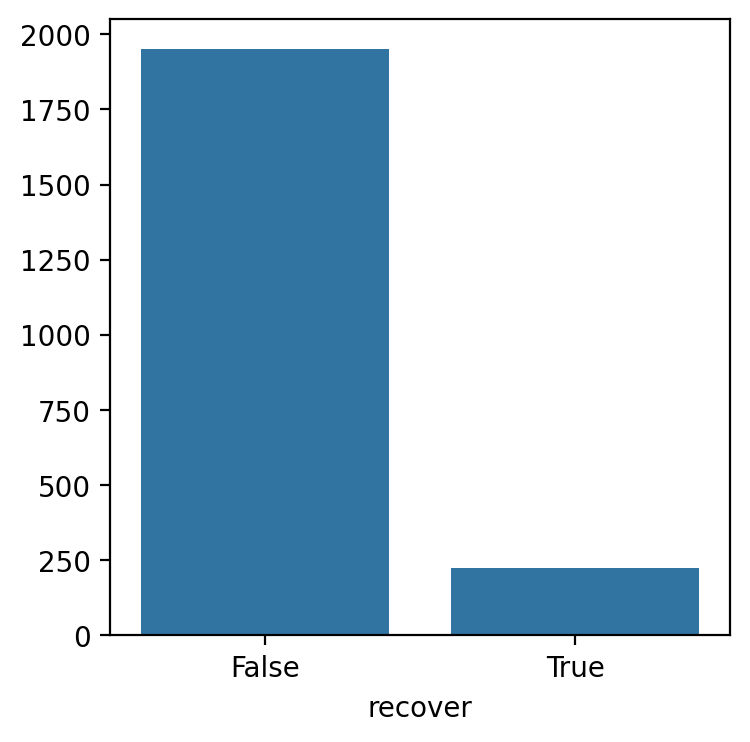

In [234]:
plt.figure(figsize=(4,4), dpi=200)
sns.barplot(x=conf_bench.value_counts('recover').index, y=conf_bench.value_counts('recover').values)

In [ ]:
def accuracy_above_threshold(df, measure = "composite_score",thresholds=None):
    df = df.copy()

    

    if thresholds is None:
        thresholds = np.linspace(0, 1, 21)  # 0.0 → 1.0 step 0.05

    rows = []

    for t in thresholds:
        subset = df[df[measure] >= t]

        if len(subset) == 0:
            acc = np.nan
        else:
            acc = subset["recover"].mean()

        rows.append({
            "threshold": t,
            "n_compounds": len(subset),
            "pct_true": acc * 100 if not np.isnan(acc) else np.nan,
            "n_compounds_true": subset["recover"].sum()
        })

    return pd.DataFrame(rows)

In [ ]:
def corr_measures_threshold(df, measure="pct_true"):
    df = df.copy()
    corr = spearmanr(df[measure], df['threshold'], nan_policy='omit')
    return corr

print('Correlation composite score all :', corr_measures_threshold(accuracy_above_threshold(conf_bench, measure="composite_score")).statistic)
print('Correlation n_sigs all :', corr_measures_threshold(accuracy_above_threshold(conf_bench, measure="score_n_sigs")).statistic)
print('Correlation tas all :', corr_measures_threshold(accuracy_above_threshold(conf_bench, measure="score_tas")).statistic)
print('Correlation enrichment all :', corr_measures_threshold(accuracy_above_threshold(conf_bench, measure="score_enrichment")).statistic)  
print('Correlation robustness_100 all :', corr_measures_threshold(accuracy_above_threshold(conf_bench, measure="score_robustness")).statistic)

Correlation composite score all : 0.9734491798677134
Correlation composite score 12cmp : 0.4968270648156314
Correlation n_sigs all : 0.996103896103896
Correlation n_sigs 12cmp : 0.7682437563337808
Correlation tas all : 0.25920499392151075
Correlation tas 12cmp : -0.7018361294903435
Correlation enrichment all : -0.40575094808527434
Correlation enrichment 12cmp : 0.6520506636966263
Correlation robustness_100 all : -0.9240929684291711
Correlation robustness_100 12cmp : 0.7831893756568048
Correlation composite_v2 all : 0.9944903161976938
Correlation composite_v2 12cmp : 0.5695573758591881


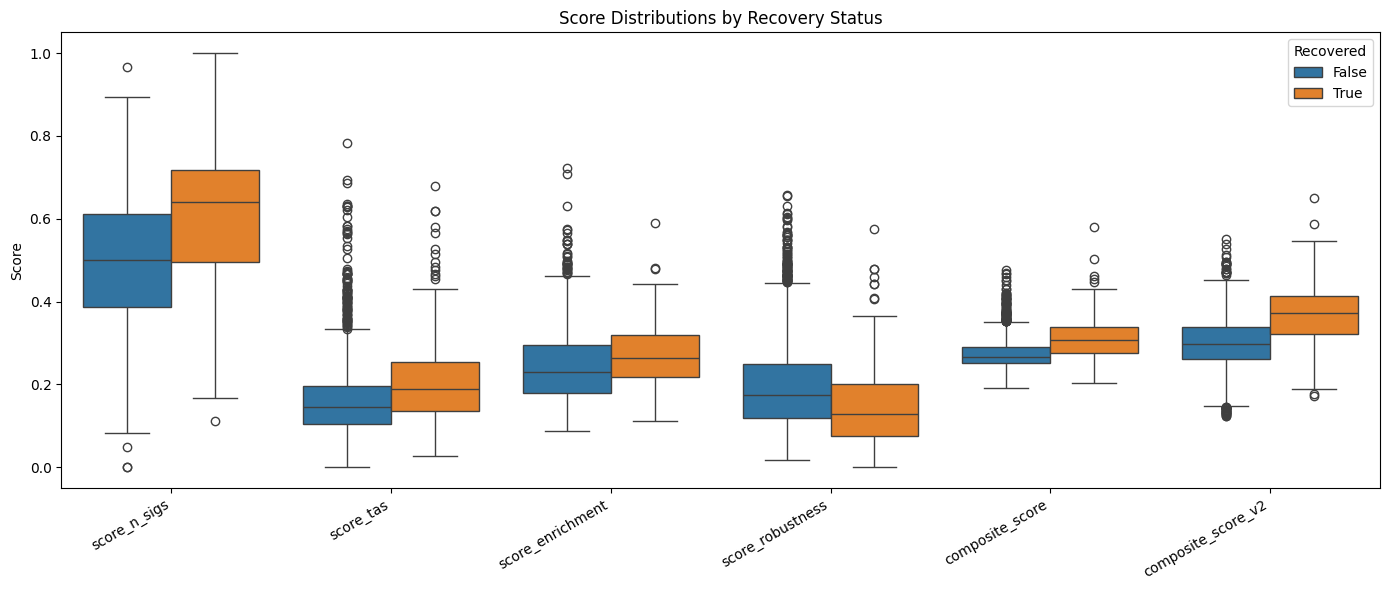

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = conf_bench

score_cols = [
    "score_n_sigs",
    "score_tas",
    "score_enrichment",
    "score_robustness",
    "composite_score",
]

# Keep only the columns we need
plot_df = df[["recover"] + score_cols].copy()

# Optional: drop rows where all scores are missing
plot_df = plot_df.dropna(how="all", subset=score_cols)

# Long format for seaborn
plot_long = plot_df.melt(
    id_vars="recover",
    value_vars=score_cols,
    var_name="metric",
    value_name="score"
)

# Remove missing values in each metric
plot_long = plot_long.dropna(subset=["score"])

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_long,
    x="metric",
    y="score",
    hue="recover"
)

plt.xticks(rotation=30, ha="right")
plt.title("Score Distributions by Recovery Status")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="Recovered")
plt.tight_layout()
plt.show()


In [238]:
accuracy_above_threshold(conf_bench, measure="composite_score")

,threshold,n_compounds,pct_true,n_compounds_true
0,0.00,2175,10.252874,223
1,0.05,2175,10.252874,223
2,0.10,2175,10.252874,223
3,0.15,2175,10.252874,223
4,0.20,2171,10.271764,223
5,0.25,1676,12.350835,207
6,0.30,492,26.016260,128
7,0.35,126,34.126984,43
8,0.40,32,28.125000,9
9,0.45,9,44.444444,4
